### Plot the basis images for a given size (8*8) and 16*16

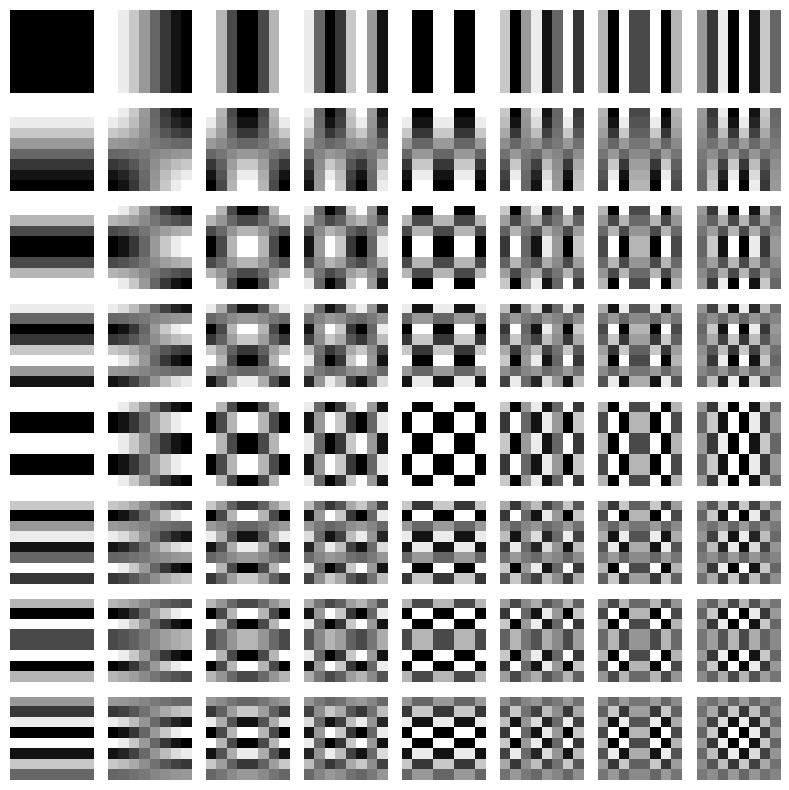

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def dct_basis(N):
    basis = np.zeros((N, N, N, N))

    def alpha(k):
        return np.sqrt(1/N) if k == 0 else np.sqrt(2/N)

    for u in range(N):
        for v in range(N):
            for x in range(N):
                for y in range(N):
                    basis[u, v, x, y] = (
                        alpha(u) * alpha(v) *
                        np.cos((2*x + 1) * u * np.pi / (2*N)) *
                        np.cos((2*y + 1) * v * np.pi / (2*N))
                    )
    return basis

def plot_dct_basis(N):
    basis = dct_basis(N)

    fig, axes = plt.subplots(N, N, figsize=(8, 8))

    for u in range(N):
        for v in range(N):
            axes[u, v].imshow(basis[u, v], cmap='gray')
            axes[u, v].axis('off')

    plt.tight_layout()
    plt.show()

# Example
plot_dct_basis(8)

### 2D DCT

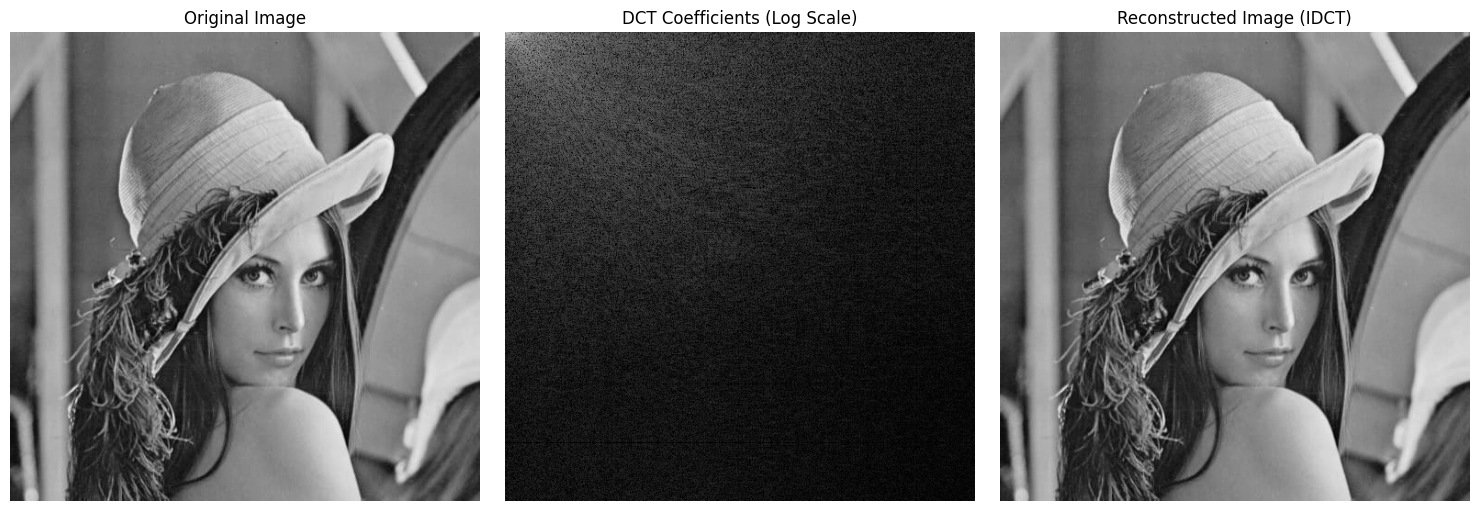

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image in grayscale
img = cv2.imread("image1.jpeg", cv2.IMREAD_GRAYSCALE)

# Convert image to float32
img_float = np.float32(img)

# Apply 2D DCT
dct = cv2.dct(img_float)

# Log scaling for better visualization
dct_log = np.log(np.abs(dct) + 1)

# Apply inverse DCT
idct = cv2.idct(dct)

# Plot results
plt.figure(figsize=(15, 5))

# Original Image
plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")

# DCT Coefficients
plt.subplot(1, 3, 2)
plt.imshow(dct_log, cmap='gray')
plt.title("DCT Coefficients (Log Scale)")
plt.axis("off")

# Reconstructed Image
plt.subplot(1, 3, 3)
plt.imshow(idct, cmap='gray')
plt.title("Reconstructed Image (IDCT)")
plt.axis("off")

plt.tight_layout()
plt.show()

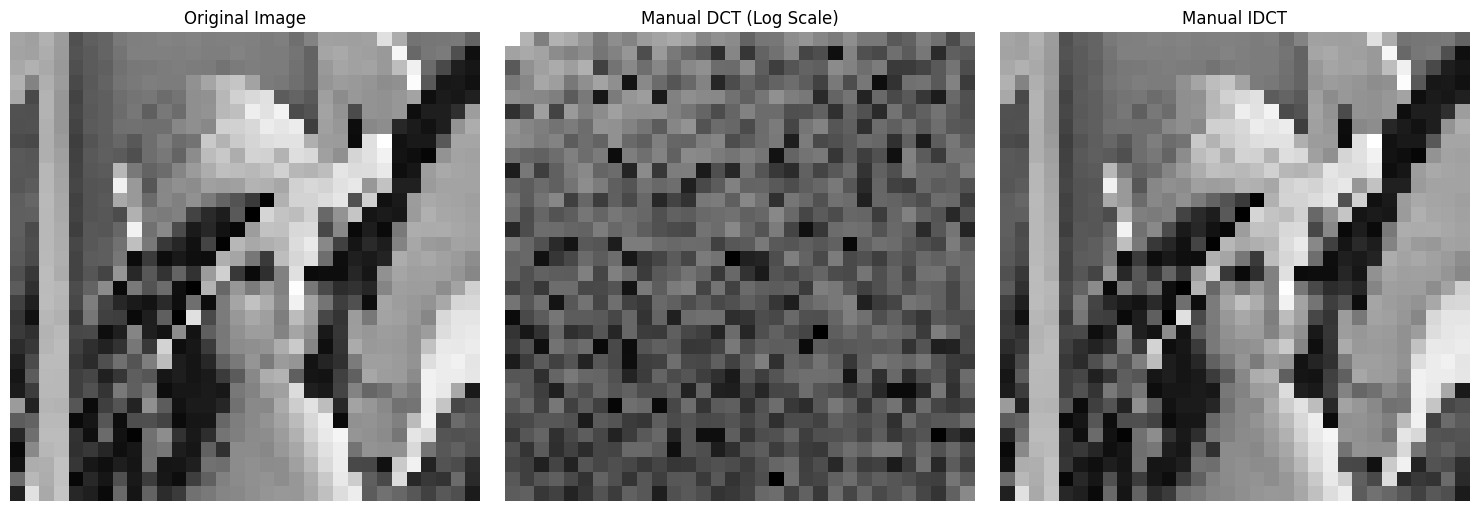

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math

# Read grayscale image
img = cv2.imread("image1.jpeg", cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (32,32))

# Convert to float
img = np.float32(img)

N, M = img.shape

# Create empty DCT matrix
dct = np.zeros((N, M))

# Manual 2D DCT
for u in range(N):
    for v in range(M):

        # Alpha values
        if u == 0:
            au = math.sqrt(1/N)
        else:
            au = math.sqrt(2/N)

        if v == 0:
            av = math.sqrt(1/M)
        else:
            av = math.sqrt(2/M)

        summation = 0

        for x in range(N):
            for y in range(M):

                term1 = math.cos(((2*x + 1) * u * math.pi) / (2 * N))
                term2 = math.cos(((2*y + 1) * v * math.pi) / (2 * M))

                summation += img[x, y] * term1 * term2

        dct[u, v] = au * av * summation

# Log scaling for visualization
dct_log = np.log(np.abs(dct) + 1)

# ---------------- IDCT ----------------

reconstructed = np.zeros((N, M))

for x in range(N):
    for y in range(M):

        summation = 0

        for u in range(N):
            for v in range(M):

                if u == 0:
                    au = math.sqrt(1/N)
                else:
                    au = math.sqrt(2/N)

                if v == 0:
                    av = math.sqrt(1/M)
                else:
                    av = math.sqrt(2/M)

                term1 = math.cos(((2*x + 1) * u * math.pi) / (2 * N))
                term2 = math.cos(((2*y + 1) * v * math.pi) / (2 * M))

                summation += au * av * dct[u, v] * term1 * term2

        reconstructed[x, y] = summation

# ---------------- Visualization ----------------

plt.figure(figsize=(15,5))

# Original
plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")

# DCT
plt.subplot(1,3,2)
plt.imshow(dct_log, cmap='gray')
plt.title("Manual DCT (Log Scale)")
plt.axis("off")

# Reconstructed
plt.subplot(1,3,3)
plt.imshow(reconstructed, cmap='gray')
plt.title("Manual IDCT")
plt.axis("off")

plt.tight_layout()
plt.show()

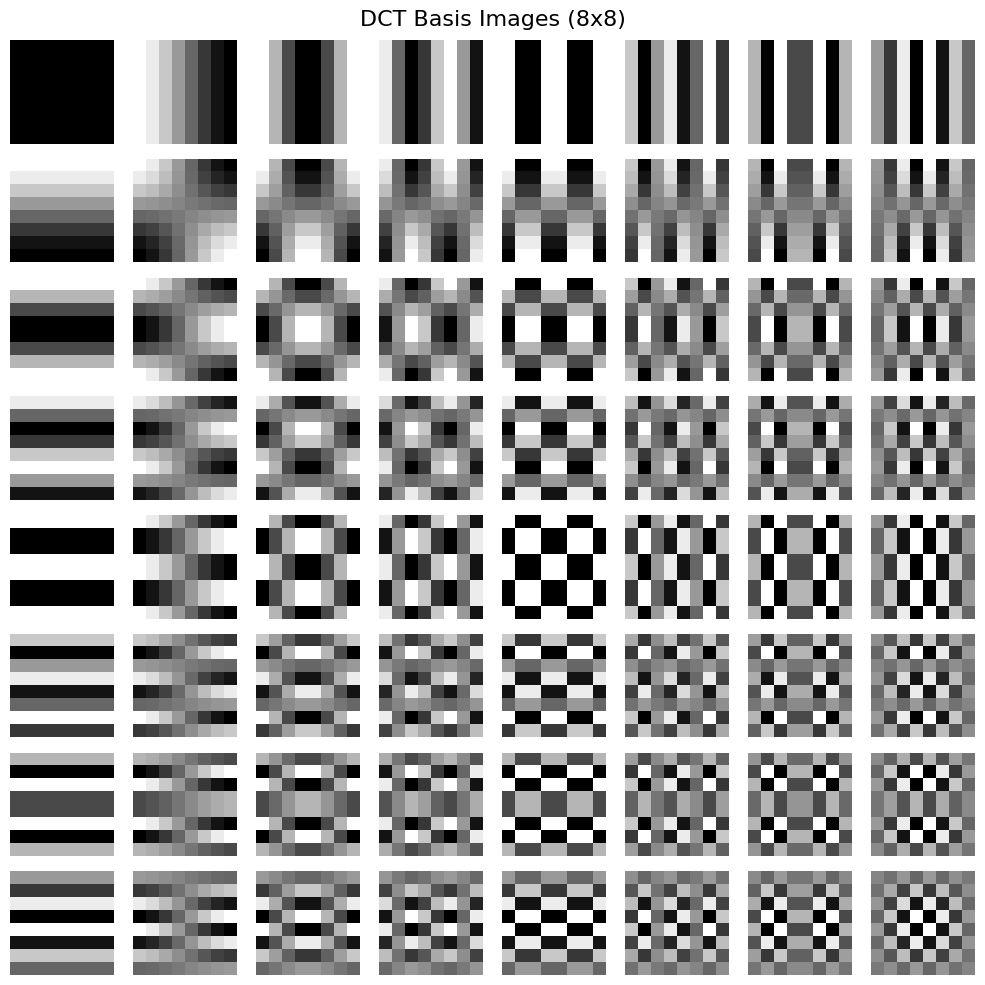

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Size of DCT
N = 8

# Alpha function
def alpha(k, N):
    if k == 0:
        return math.sqrt(1 / N)
    else:
        return math.sqrt(2 / N)

# Create figure
fig, axes = plt.subplots(N, N, figsize=(10,10))

# Generate basis images
for u in range(N):
    for v in range(N):

        basis = np.zeros((N, N))

        for x in range(N):
            for y in range(N):

                basis[x, y] = (
                    alpha(u, N)
                    * alpha(v, N)
                    * math.cos(((2*x + 1) * u * math.pi) / (2 * N))
                    * math.cos(((2*y + 1) * v * math.pi) / (2 * N))
                )

        # Display basis image
        axes[u, v].imshow(basis, cmap='gray')

        axes[u, v].axis('off')

# Title
plt.suptitle("DCT Basis Images (8x8)", fontsize=16)

plt.tight_layout()
plt.show()

### 2D DFT

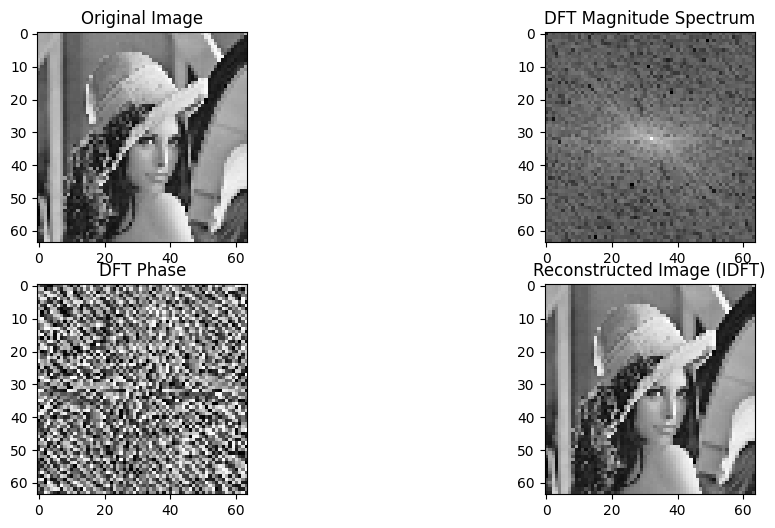

In [6]:
import numpy as np
import cv2
import matplotlib.pyplot as plt


def dft2d(image):

    M, N = image.shape
    F = np.zeros((M, N), dtype=complex)

    for u in range(M):
        for v in range(N):

            sum_val = 0

            for x in range(M):
                for y in range(N):

                    angle = -2j * np.pi * ((u*x/M) + (v*y/N))
                    sum_val += image[x,y] * np.exp(angle)

            F[u,v] = sum_val

    return F



def idft2d(F):

    M, N = F.shape
    image = np.zeros((M, N), dtype=complex)

    for x in range(M):
        for y in range(N):

            sum_val = 0

            for u in range(M):
                for v in range(N):

                    angle = 2j * np.pi * ((u*x/M) + (v*y/N))
                    sum_val += F[u,v] * np.exp(angle)

            image[x,y] = sum_val / (M*N)

    return np.real(image)



img = cv2.imread('image1.jpeg', 0)


img = cv2.resize(img,(64,64))


F = dft2d(img)
F_shift = np.fft.fftshift(F)

magnitude = np.log(1 + np.abs(F_shift))


phase = np.angle(F_shift)

reconstructed = idft2d(F)



plt.figure(figsize=(12,6))

plt.subplot(221)
plt.title("Original Image")
plt.imshow(img, cmap='gray')

plt.subplot(222)
plt.title("DFT Magnitude Spectrum")
plt.imshow(magnitude, cmap='gray')

plt.subplot(223)
plt.title("DFT Phase")
plt.imshow(phase, cmap='gray')

plt.subplot(224)
plt.title("Reconstructed Image (IDFT)")
plt.imshow(reconstructed, cmap='gray')

plt.show()

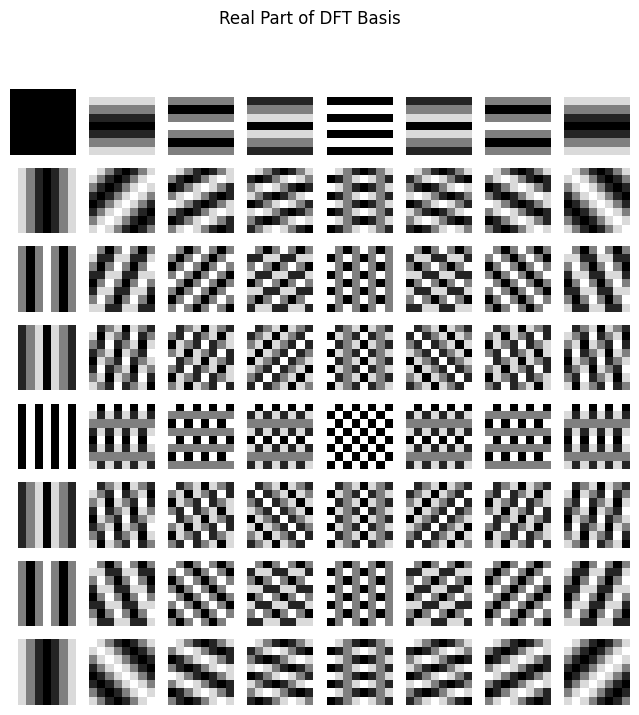

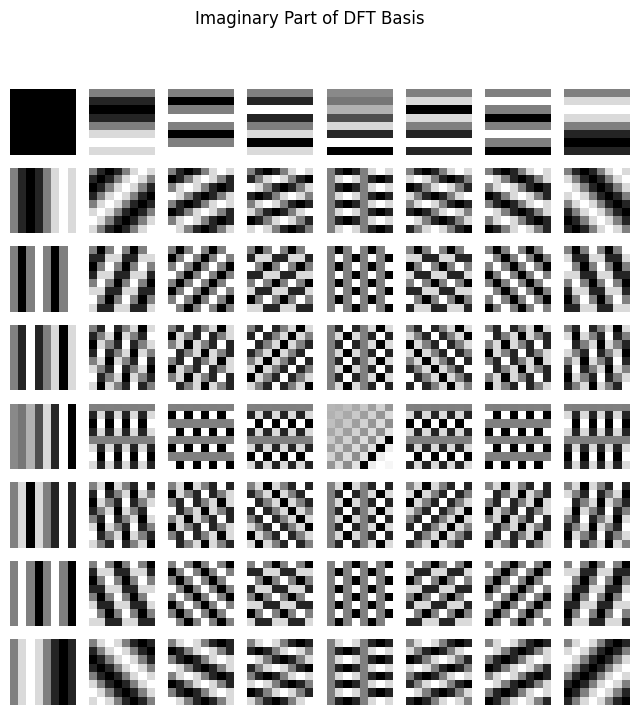

In [7]:
import numpy as np
import matplotlib.pyplot as plt


def plot_dft_basis(N):

    x = np.arange(N)
    y = np.arange(N)

    X, Y = np.meshgrid(x, y)

    fig_real, ax_real = plt.subplots(N, N, figsize=(8,8))
    fig_real.suptitle("Real Part of DFT Basis")

    fig_imag, ax_imag = plt.subplots(N, N, figsize=(8,8))
    fig_imag.suptitle("Imaginary Part of DFT Basis")

    for u in range(N):
        for v in range(N):

            basis = np.exp(-2j * np.pi * ((u*X/N) + (v*Y/N)))

            real_part = np.real(basis)
            imag_part = np.imag(basis)

            ax_real[u,v].imshow(real_part, cmap='gray')
            ax_real[u,v].axis('off')

            ax_imag[u,v].imshow(imag_part, cmap='gray')
            ax_imag[u,v].axis('off')

    plt.show()



plot_dft_basis(8)

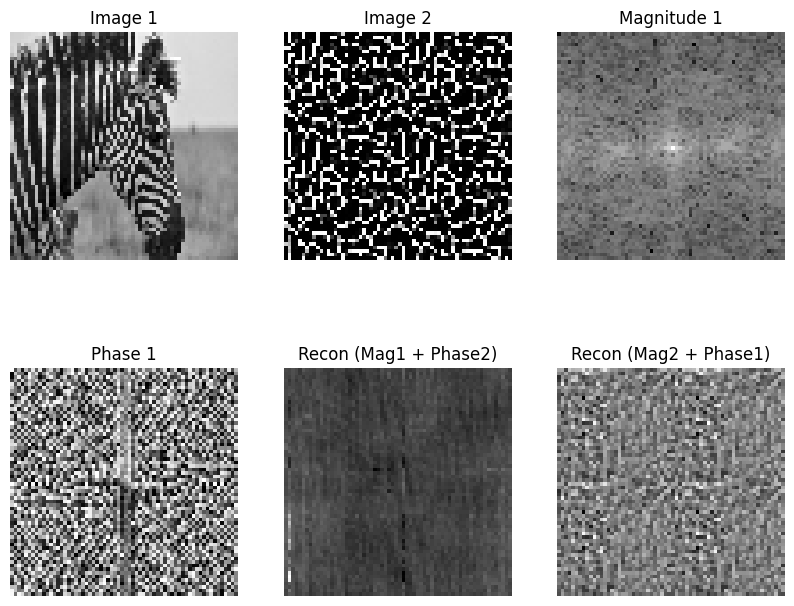

In [9]:
import numpy as np
import cv2
import matplotlib.pyplot as plt



img1 = cv2.imread('zebra.jpeg', 0)
img2 = cv2.imread('giraffepattern.jpg', 0)


img1 = cv2.resize(img1, (64,64))
img2 = cv2.resize(img2, (64,64))



F1 = np.fft.fft2(img1)
F2 = np.fft.fft2(img2)
F1 = np.fft.fftshift(F1)
F2 = np.fft.fftshift(F2)


mag1 = np.abs(F1)
mag2 = np.abs(F2)

phase1 = np.angle(F1)
phase2 = np.angle(F2)



swap1 = mag1 * np.exp(1j * phase2)
swap2 = mag2 * np.exp(1j * phase1)



swap1 = np.fft.ifftshift(swap1)
swap2 = np.fft.ifftshift(swap2)

recon1 = np.fft.ifft2(swap1)
recon2 = np.fft.ifft2(swap2)

recon1 = np.real(recon1)
recon2 = np.real(recon2)

plt.figure(figsize=(10,8))

plt.subplot(231)
plt.title("Image 1")
plt.imshow(img1, cmap='gray')
plt.axis('off')

plt.subplot(232)
plt.title("Image 2")
plt.imshow(img2, cmap='gray')
plt.axis('off')

plt.subplot(233)
plt.title("Magnitude 1")
plt.imshow(np.log(1+mag1), cmap='gray')
plt.axis('off')

plt.subplot(234)
plt.title("Phase 1")
plt.imshow(phase1, cmap='gray')
plt.axis('off')

plt.subplot(235)
plt.title("Recon (Mag1 + Phase2)")
plt.imshow(recon1, cmap='gray')
plt.axis('off')

plt.subplot(236)
plt.title("Recon (Mag2 + Phase1)")
plt.imshow(recon2, cmap='gray')
plt.axis('off')

plt.show()

### Correlation

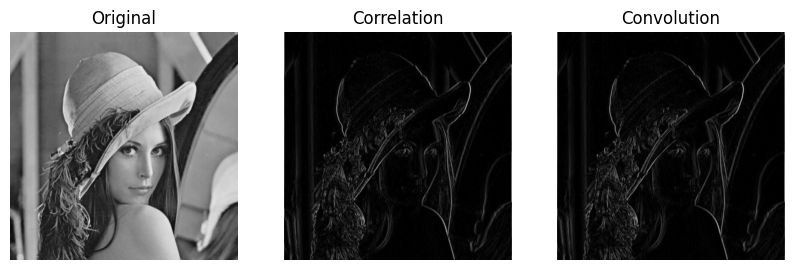

In [11]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt


def correlation(image, kernel):

    k = kernel.shape[0]
    pad = k // 2

    padded = np.pad(image, pad, mode='constant')
    output = np.zeros(image.shape, dtype=np.float32)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):

            region = padded[i:i+k, j:j+k]
            output[i,j] = np.sum(region * kernel)

    return output


def convolution(image, kernel):

    kernel_flipped = np.flip(kernel)

    k = kernel.shape[0]
    pad = k // 2

    padded = np.pad(image, pad, mode='constant')
    output = np.zeros(image.shape, dtype=np.float32)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):

            region = padded[i:i+k, j:j+k]
            output[i,j] = np.sum(region * kernel_flipped)

    return output



image = cv.imread('image1.jpeg', 0)



kernel = np.array([
    [1,0,-1],
    [1,0,-1],
    [1,0,-1]
])


corr = correlation(image, kernel)
conv = convolution(image, kernel)



corr = np.abs(corr)
conv = np.abs(conv)

corr = (corr / corr.max()) * 255
conv = (conv / conv.max()) * 255

corr = corr.astype(np.uint8)
conv = conv.astype(np.uint8)


plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(image, cmap='gray')
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Correlation")
plt.imshow(corr, cmap='gray')
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Convolution")
plt.imshow(conv, cmap='gray')
plt.axis('off')

plt.show()

### Edge detection using sobel

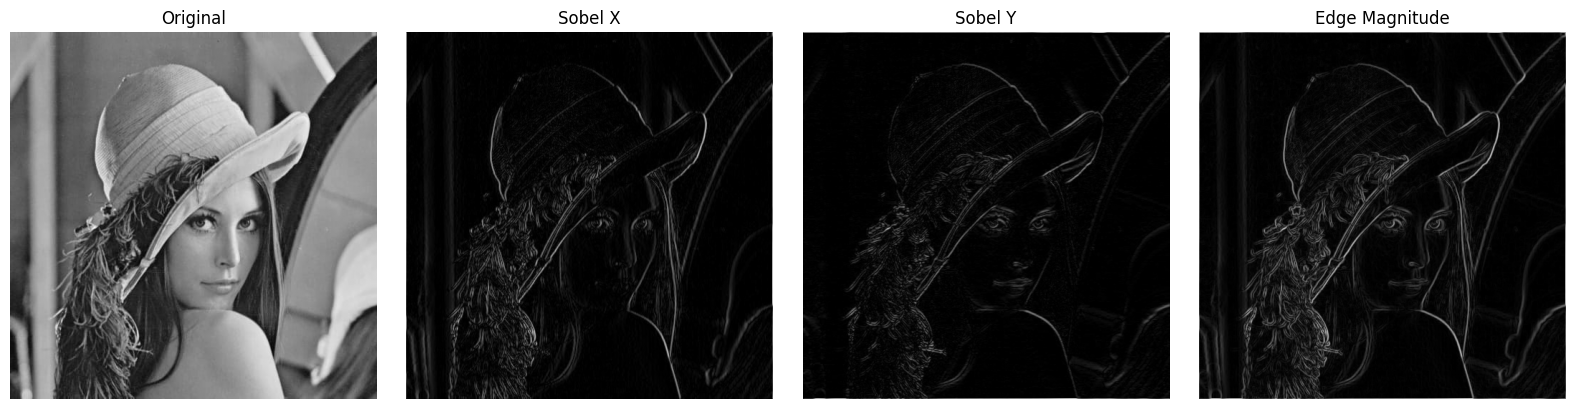

In [13]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt


def convolution(image, kernel):

    k = kernel.shape[0]
    pad = k // 2

    padded = np.pad(image, pad, mode='constant')
    output = np.zeros_like(image, dtype=float)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):

            region = padded[i:i+k, j:j+k]
            output[i,j] = np.sum(region * kernel)

    return output



image = cv.imread("image1.jpeg", 0)



sobel_x = np.array([
[-1,0,1],
[-2,0,2],
[-1,0,1]
])

sobel_y = np.array([
[-1,-2,-1],
[0,0,0],
[1,2,1]
])



gx = convolution(image, sobel_x)
gy = convolution(image, sobel_y)



edges = np.sqrt(gx**2 + gy**2)



gx_disp = np.abs(gx)
gy_disp = np.abs(gy)

gx_disp = (gx_disp / gx_disp.max()) * 255
gy_disp = (gy_disp / gy_disp.max()) * 255
edges = (edges / edges.max()) * 255

gx_disp = gx_disp.astype(np.uint8)
gy_disp = gy_disp.astype(np.uint8)
edges = edges.astype(np.uint8)



plt.figure(figsize=(16,4))

plt.subplot(1,4,1)
plt.title("Original")
plt.imshow(image, cmap='gray')
plt.axis('off')

plt.subplot(1,4,2)
plt.title("Sobel X")
plt.imshow(gx_disp, cmap='gray')
plt.axis('off')

plt.subplot(1,4,3)
plt.title("Sobel Y")
plt.imshow(gy_disp, cmap='gray')
plt.axis('off')

plt.subplot(1,4,4)
plt.title("Edge Magnitude")
plt.imshow(edges, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

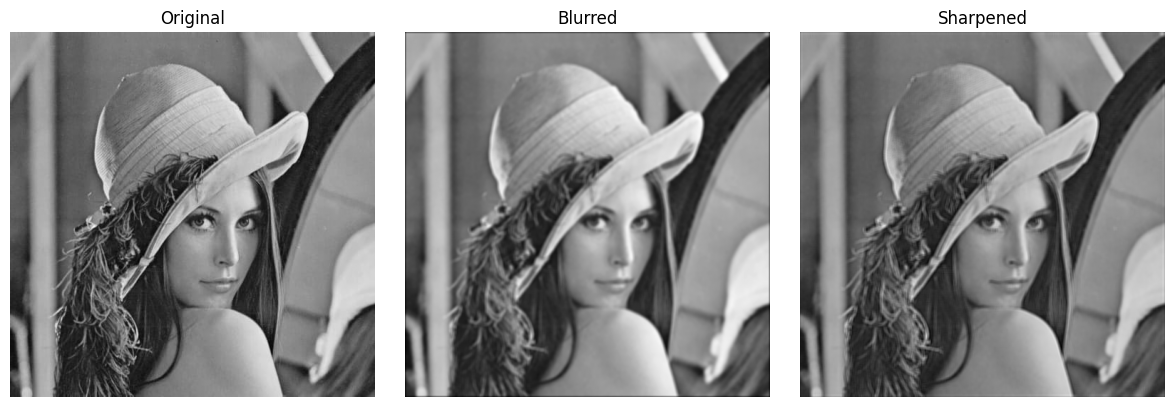

In [15]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt


def convolution(image, kernel):

    k = kernel.shape[0]
    pad = k // 2

    padded = np.pad(image, pad, mode='constant')
    output = np.zeros_like(image, dtype=float)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):

            region = padded[i:i+k, j:j+k]
            output[i,j] = np.sum(region * kernel)

    return output



image = cv.imread("image1.jpeg", 0)



blur_kernel = np.ones((5,5)) / 25
blurred = convolution(image, blur_kernel)



sharpen_kernel = np.array([
[0,-1,0],
[-1,5,-1],
[0,-1,0]
])



sharpened = convolution(blurred, sharpen_kernel)



blurred = (blurred / blurred.max()) * 255
sharpened = (sharpened / sharpened.max()) * 255

blurred = blurred.astype(np.uint8)
sharpened = sharpened.astype(np.uint8)


plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(image, cmap='gray')
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Blurred")
plt.imshow(blurred, cmap='gray')
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Sharpened")
plt.imshow(sharpened, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

### Smoothing averaging filter

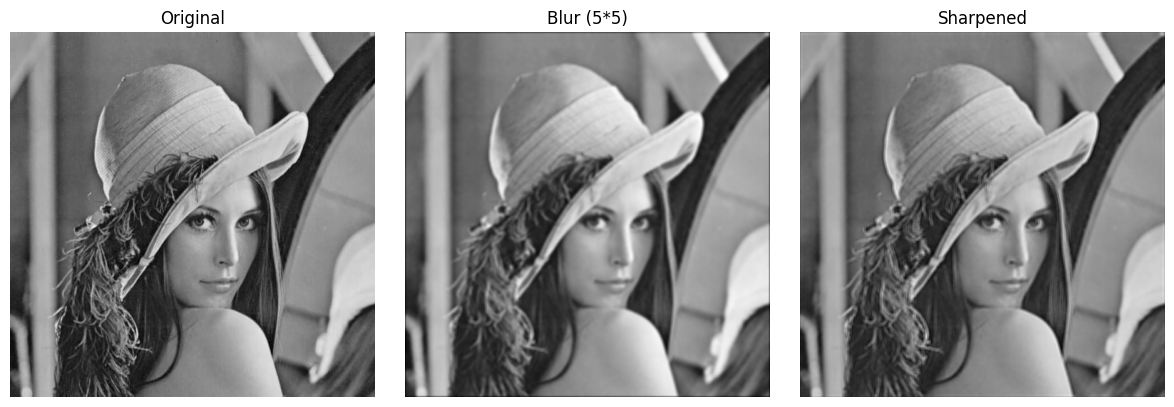

In [17]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt


def convolution(image, kernel):

    k = kernel.shape[0]
    pad = k // 2

    padded = np.pad(image, pad, mode='constant')
    output = np.zeros_like(image, dtype=float)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):

            region = padded[i:i+k, j:j+k]
            output[i,j] = np.sum(region * kernel)

    return output



image = cv.imread("image1.jpeg", 0)



blur_kernel = np.ones((5,5)) / 25
blurred = convolution(image, blur_kernel)



sharpen_kernel = np.array([
[0,1,0],
[1,-4,1],
[0,1,0]
])



sharpened = convolution(blurred, sharpen_kernel)
sharpened = blurred - sharpened


blurred = np.clip(blurred, 0, 255)
sharpened = np.clip(sharpened, 0, 255)

blurred = blurred.astype(np.uint8)
sharpened = sharpened.astype(np.uint8)


plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(image, cmap='gray')
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Blur (5*5)")
plt.imshow(blurred, cmap='gray')
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Sharpened")
plt.imshow(sharpened, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

### GLCM

In [23]:
import numpy as np


def build_glcm(image, d, theta, levels):

    # Create empty GLCM
    glcm = np.zeros((levels, levels), dtype=np.float32)

    # Define direction
    if theta == 0:
        dx, dy = 0, d

    elif theta == 45:
        dx, dy = -d, d

    elif theta == 90:
        dx, dy = -d, 0

    elif theta == 135:
        dx, dy = -d, -d

    else:
        raise ValueError("Unsupported angle")


    rows, cols = image.shape


    # Traverse image
    for i in range(rows):
        for j in range(cols):

            neighbor_i = i + dx
            neighbor_j = j + dy


            # Boundary check
            if (0 <= neighbor_i < rows) and (0 <= neighbor_j < cols):

                current_pixel = image[i, j]
                neighbor_pixel = image[neighbor_i, neighbor_j]

                glcm[current_pixel, neighbor_pixel] += 1


    return glcm


image = np.array([
    [0, 1, 1, 2],
    [0, 0, 1, 2],
    [2, 2, 1, 0],
    [1, 0, 0, 2]
])

levels = 3
glcm = build_glcm(image, d=1, theta=0, levels=3)
print(glcm)

glcm = glcm / glcm.sum()
contrast = 0

for i in range(levels):
    for j in range(levels):

        contrast += ((i - j) ** 2) * glcm[i,j]


energy = 0

for i in range(levels):
    for j in range(levels):

        energy += glcm[i,j] ** 2


homogeneity = 0

for i in range(levels):
    for j in range(levels):

        homogeneity += glcm[i,j] / (1 + abs(i - j))


# Correlation

mu_i = 0
mu_j = 0

for i in range(levels):
    for j in range(levels):

        mu_i += i * glcm[i,j]
        mu_j += j * glcm[i,j]


sigma_i = 0
sigma_j = 0

for i in range(levels):
    for j in range(levels):

        sigma_i += ((i - mu_i) ** 2) * glcm[i,j]
        sigma_j += ((j - mu_j) ** 2) * glcm[i,j]


sigma_i = np.sqrt(sigma_i)
sigma_j = np.sqrt(sigma_j)


if sigma_i == 0 or sigma_j == 0:

    correlation = 0

else:

    correlation = 0

    for i in range(levels):
        for j in range(levels):

            correlation += (
                ((i - mu_i) * (j - mu_j) * glcm[i,j])
                / (sigma_i * sigma_j)
            )

print(contrast , energy , homogeneity , correlation)

[[2. 2. 1.]
 [2. 1. 2.]
 [0. 1. 1.]]
0.9166667 0.13888891 0.6527778 0.28284273


In [1]:
import numpy as np
import cv2 as cv


def build_glcm(image, d, theta, levels):

    # Create empty GLCM
    glcm = np.zeros((levels, levels), dtype=np.float32)

    # Define direction
    if theta == 0:
        dx, dy = 0, d

    elif theta == 45:
        dx, dy = -d, d

    elif theta == 90:
        dx, dy = -d, 0

    elif theta == 135:
        dx, dy = -d, -d

    else:
        raise ValueError("Unsupported angle")


    rows, cols = image.shape


    # Traverse image
    for i in range(rows):
        for j in range(cols):

            neighbor_i = i + dx
            neighbor_j = j + dy


            # Boundary check
            if (0 <= neighbor_i < rows) and (0 <= neighbor_j < cols):

                current_pixel = image[i, j]
                neighbor_pixel = image[neighbor_i, neighbor_j]

                glcm[current_pixel, neighbor_pixel] += 1


    return glcm



def extract_features(glcm, levels):

    # Normalize GLCM
    glcm = glcm / glcm.sum()


    # Contrast
    contrast = 0

    for i in range(levels):
        for j in range(levels):

            contrast += ((i - j) ** 2) * glcm[i,j]


    # Energy
    energy = 0

    for i in range(levels):
        for j in range(levels):

            energy += glcm[i,j] ** 2


    # Homogeneity
    homogeneity = 0

    for i in range(levels):
        for j in range(levels):

            homogeneity += glcm[i,j] / (1 + abs(i - j))


    # Correlation

    mu_i = 0
    mu_j = 0

    for i in range(levels):
        for j in range(levels):

            mu_i += i * glcm[i,j]
            mu_j += j * glcm[i,j]


    sigma_i = 0
    sigma_j = 0

    for i in range(levels):
        for j in range(levels):

            sigma_i += ((i - mu_i) ** 2) * glcm[i,j]
            sigma_j += ((j - mu_j) ** 2) * glcm[i,j]


    sigma_i = np.sqrt(sigma_i)
    sigma_j = np.sqrt(sigma_j)


    if sigma_i == 0 or sigma_j == 0:

        correlation = 0

    else:

        correlation = 0

        for i in range(levels):
            for j in range(levels):

                correlation += (
                    ((i - mu_i) * (j - mu_j) * glcm[i,j])
                    / (sigma_i * sigma_j)
                )


    return contrast, energy, homogeneity, correlation



# ---------------------------------------------------
# Read real grayscale image
# ---------------------------------------------------

image = cv.imread("image1.jpeg", 0)

if image is None:
    print("Image not found")
    exit()


# ---------------------------------------------------
# Quantize image
# Convert 0-255 -> 0-7
# ---------------------------------------------------

levels = 8

image = image // 32


# ---------------------------------------------------
# Build GLCM
# ---------------------------------------------------

glcm = build_glcm(
    image=image,
    d=1,
    theta=0,
    levels=levels
)


# ---------------------------------------------------
# Extract Features
# ---------------------------------------------------

features = extract_features(glcm, levels)


# ---------------------------------------------------
# Print Results
# ---------------------------------------------------

print("GLCM Matrix:\n")
print(glcm)

print("\nFeatures:\n")
print("Contrast    :", features[0])
print("Energy      :", features[1])
print("Homogeneity :", features[2])
print("Correlation :", features[3])

GLCM Matrix:

[[1.5700e+02 3.6700e+02 1.9000e+01 2.0000e+00 0.0000e+00 0.0000e+00
  0.0000e+00 0.0000e+00]
 [3.3500e+02 3.6536e+04 4.4370e+03 3.0900e+02 1.4000e+01 0.0000e+00
  0.0000e+00 0.0000e+00]
 [4.2000e+01 4.1950e+03 2.1857e+04 4.3700e+03 4.0200e+02 2.3000e+01
  3.0000e+00 0.0000e+00]
 [3.0000e+00 4.4400e+02 4.0800e+03 4.5338e+04 4.6230e+03 2.2900e+02
  2.8000e+01 0.0000e+00]
 [0.0000e+00 6.8000e+01 3.6000e+02 4.3390e+03 6.6132e+04 3.1520e+03
  9.3000e+01 2.0000e+00]
 [0.0000e+00 7.0000e+00 7.0000e+01 2.3100e+02 2.9090e+03 3.0601e+04
  1.6830e+03 1.5000e+01]
 [0.0000e+00 0.0000e+00 7.0000e+00 3.4000e+01 1.8300e+02 1.4930e+03
  2.1745e+04 2.0700e+02]
 [0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 1.0000e+00 1.7000e+01
  2.0600e+02 2.6400e+02]]

Features:

Contrast    : 0.1844155
Energy      : 0.14300252
Homogeneity : 0.92371726
Correlation : 0.9597591


In [ ]:
import os
import numpy as np
import cv2 as cv

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix



# ---------------------------------------------------
# Build GLCM
# ---------------------------------------------------

def build_glcm(image, d, theta, levels):

    glcm = np.zeros((levels, levels), dtype=np.float32)

    if theta == 0:
        dx, dy = 0, d

    elif theta == 45:
        dx, dy = -d, d

    elif theta == 90:
        dx, dy = -d, 0

    elif theta == 135:
        dx, dy = -d, -d

    else:
        raise ValueError("Unsupported angle")


    rows, cols = image.shape


    for i in range(rows):
        for j in range(cols):

            neighbor_i = i + dx
            neighbor_j = j + dy

            if (0 <= neighbor_i < rows) and (0 <= neighbor_j < cols):

                current_pixel = image[i, j]
                neighbor_pixel = image[neighbor_i, neighbor_j]

                glcm[current_pixel, neighbor_pixel] += 1


    return glcm



# ---------------------------------------------------
# Extract Features
# ---------------------------------------------------

def extract_features(glcm, levels):

    glcm = glcm / glcm.sum()


    # Contrast
    contrast = 0

    for i in range(levels):
        for j in range(levels):

            contrast += ((i - j) ** 2) * glcm[i,j]


    # Energy
    energy = 0

    for i in range(levels):
        for j in range(levels):

            energy += glcm[i,j] ** 2


    # Homogeneity
    homogeneity = 0

    for i in range(levels):
        for j in range(levels):

            homogeneity += glcm[i,j] / (1 + abs(i - j))


    # Correlation

    mu_i = 0
    mu_j = 0

    for i in range(levels):
        for j in range(levels):

            mu_i += i * glcm[i,j]
            mu_j += j * glcm[i,j]


    sigma_i = 0
    sigma_j = 0

    for i in range(levels):
        for j in range(levels):

            sigma_i += ((i - mu_i) ** 2) * glcm[i,j]
            sigma_j += ((j - mu_j) ** 2) * glcm[i,j]


    sigma_i = np.sqrt(sigma_i)
    sigma_j = np.sqrt(sigma_j)


    if sigma_i == 0 or sigma_j == 0:

        correlation = 0

    else:

        correlation = 0

        for i in range(levels):
            for j in range(levels):

                correlation += (
                    ((i - mu_i) * (j - mu_j) * glcm[i,j])
                    / (sigma_i * sigma_j)
                )


    return [contrast, energy, homogeneity, correlation]



# ---------------------------------------------------
# Dataset Path
# ---------------------------------------------------

dataset_path = "dataset"

# Example:
#
# dataset/
#    brick/
#    grass/
#    wood/


# ---------------------------------------------------
# Parameters
# ---------------------------------------------------

levels = 8


# ---------------------------------------------------
# Feature Dataset
# ---------------------------------------------------

X = []
y = []


# ---------------------------------------------------
# Traverse Dataset
# ---------------------------------------------------

for class_name in os.listdir(dataset_path):

    class_path = os.path.join(dataset_path, class_name)

    if not os.path.isdir(class_path):
        continue


    for file in os.listdir(class_path):

        image_path = os.path.join(class_path, file)

        image = cv.imread(image_path, 0)

        if image is None:
            continue


        # Resize image
        image = cv.resize(image, (128, 128))


        # Quantization
        image = image // 32


        # Build GLCM
        glcm = build_glcm(
            image=image,
            d=1,
            theta=0,
            levels=levels
        )


        # Extract Features
        features = extract_features(glcm, levels)


        # Store
        X.append(features)
        y.append(class_name)



# ---------------------------------------------------
# Convert to numpy arrays
# ---------------------------------------------------

X = np.array(X)
y = np.array(y)


print("Feature Dataset Shape:", X.shape)
print("Labels Shape:", y.shape)



# ---------------------------------------------------
# Train Test Split
# ---------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)



# ---------------------------------------------------
# Train Classifier
# ---------------------------------------------------

model = SVC(kernel='rbf')

model.fit(X_train, y_train)



# ---------------------------------------------------
# Predictions
# ---------------------------------------------------

y_pred = model.predict(X_test)



# ---------------------------------------------------
# Evaluation
# ---------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)


cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:\n")
print(cm)